In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

### Train a model for a single config file

In [2]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU or MacOS with Metal support
if torch.cuda.is_available() or torch.backends.mps.is_available():
    start_run(config_file=Path("1_basin.yml"))

# fall back to CPU-only mode
else:
    start_run(config_file=Path("1_basin.yml"), gpu=-1)

2026-09-11 11:26:11,345: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-MinLSTM/runs/test_minlstm_1109_112611/output.log initialized.
2026-09-11 11:26:11,346: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-MinLSTM/runs/test_minlstm_1109_112611
2026-09-11 11:26:11,346: ### Run configurations for test_minlstm
2026-09-11 11:26:11,346: experiment_name: test_minlstm
2026-09-11 11:26:11,347: train_basin_file: 1_basin.txt
2026-09-11 11:26:11,347: validation_basin_file: 1_basin.txt
2026-09-11 11:26:11,348: test_basin_file: 1_basin.txt
2026-09-11 11:26:11,349: train_start_date: 1999-10-01 00:00:00
2026-09-11 11:26:11,349: train_end_date: 2008-09-30 00:00:00
2026-09-11 11:26:11,349: validation_start_date: 1980-10-01 00:00:00
2026-09-11 11:26:11,349: validation_end_date: 1989-09-30 00:00

### Evaluate run on test set
The run directory that needs to be specified for evaluation is printed in the output log above. Since the folder name is created dynamically (including the date and time of the start of the run) you will need to change the `run_dir` argument according to your local directory name. By default, it will use the same device as during the training process.

In [3]:
run_dir = Path("runs/test_minlstm_1109_112611")
eval_run(run_dir=run_dir, period="test")

2026-09-11 11:29:42,159: Using the model weights from runs/test_minlstm_1109_112611/model_epoch002.pt
# Evaluation: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]
2026-09-11 11:29:43,427: Stored metrics at runs/test_minlstm_1109_112611/test/model_epoch002/test_metrics.csv
2026-09-11 11:29:43,429: Stored results at runs/test_minlstm_1109_112611/test/model_epoch002/test_results.p


### Load and inspect model predictions
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

In [5]:
with open(run_dir / "test" / "model_epoch002" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
results.keys()

dict_keys(['01022500'])

The data variables in the xarray Dataset are named according to the name of the target variables, with suffix `_obs` for the observations and suffix `_sim` for the simulations.

In [6]:
results['01022500']['1D']['xr']

<xarray.Dataset> Size: 58kB
Dimensions:         (date: 3652, time_step: 1)
Coordinates:
  * date            (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
  * time_step       (time_step) int64 8B 0
Data variables:
    QObs(mm/d)_obs  (date, time_step) float32 15kB 0.6203 0.5537 ... 0.9992
    QObs(mm/d)_sim  (date, time_step) float32 15kB 0.4805 0.4773 ... 1.72 1.373

Let's plot the model predictions vs. the observations

Text(0.5, 1.0, 'Test period - NSE 0.574')

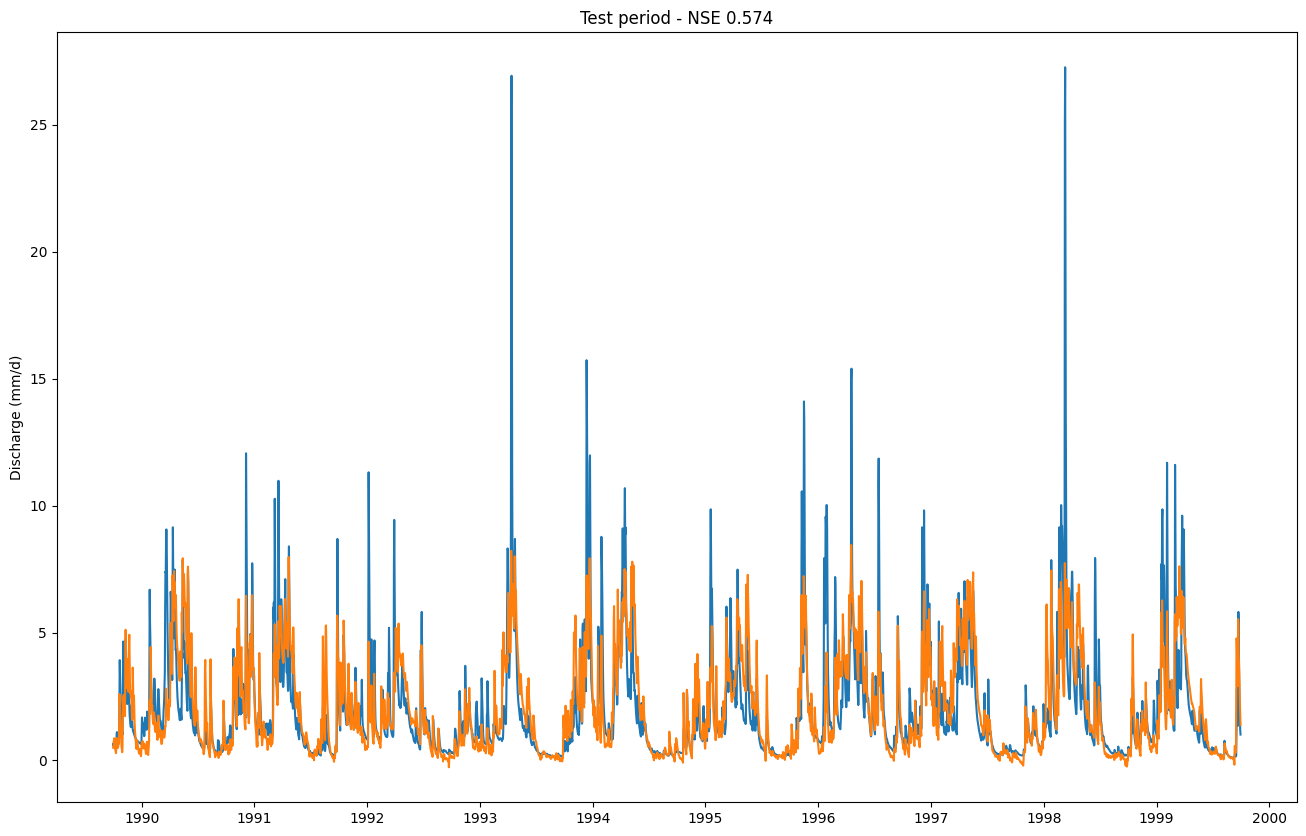

In [7]:
# extract observations and simulations
qobs = results['01022500']['1D']['xr']['QObs(mm/d)_obs']
qsim = results['01022500']['1D']['xr']['QObs(mm/d)_sim']

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['date'], qobs)
ax.plot(qsim['date'], qsim)
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Test period - NSE {results['01022500']['1D']['NSE']:.3f}")

Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [7]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.777
MSE: 1.099
RMSE: 1.048
KGE: 0.850
Alpha-NSE: 0.921
Beta-NSE: 0.048
Pearson-r: 0.883
FHV: -9.371
FMS: -2.198
FLV: -877.436
Peak-Timing: 0.174
